# Challenge 5 — Comparative Analysis of Clustering Algorithms

## Public Health & Epidemiology

This notebook compares the performance and structural behavior of three unsupervised learning algorithms applied to the BRFSS dataset:

- K-Means
- DBSCAN
- Hierarchical Agglomerative Clustering

The objective is to evaluate how different clustering paradigms capture epidemiological structures, population heterogeneity, and latent health-related patterns.

The comparison includes:
- quantitative evaluation metrics,
- geometric behavior,
- density sensitivity,
- robustness to continuous structures,
- and interpretability considerations.

In [1]:
# =========================================================
# COMPARATIVE ANALYSIS
# =========================================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully.")

Libraries loaded successfully.


# Consolidated Evaluation Metrics

The following metrics are used to compare clustering performance:

- **Silhouette Score**: measures cluster cohesion and separation
- **Davies-Bouldin Index**: evaluates intra/inter-cluster similarity (lower is better)
- **Calinski-Harabasz Index**: measures cluster compactness and separation

Each algorithm captures different structural assumptions:
- K-Means emphasizes centroid-based partitioning
- DBSCAN emphasizes density connectivity
- Hierarchical Clustering emphasizes nested relationships

In [2]:
# =========================
# Consolidated Metrics
# =========================

comparison_df = pd.DataFrame({
    "Algorithm": [
        "K-Means",
        "DBSCAN",
        "Hierarchical"
    ],
    
    "Silhouette Score": [
        0.1592,
        0.2047,
        0.1691
    ],
    
    "Davies-Bouldin": [
        1.9164,
        1.5576,
        1.7875
    ],
    
    "Calinski-Harabasz": [
        2874.74,
        267.32,
        465.52
    ]
})

comparison_df

,Algorithm,Silhouette Score,Davies-Bouldin,Calinski-Harabasz
0,K-Means,0.1592,1.9164,2874.74
1,DBSCAN,0.2047,1.5576,267.32
2,Hierarchical,0.1691,1.7875,465.52


# Metrics Visualization

Visual comparison of clustering evaluation metrics provides insight into:
- cluster separation,
- compactness,
- and structural quality.

Different metrics emphasize distinct aspects of clustering behavior, so results should be interpreted jointly rather than independently.

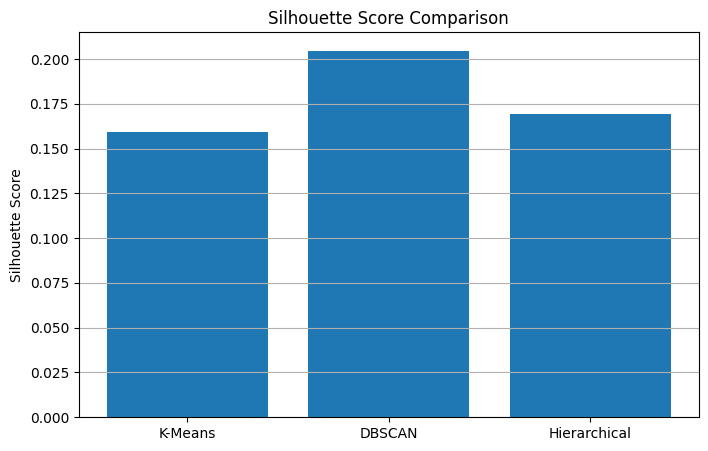

In [3]:
# =========================
# Silhouette Comparison
# =========================

plt.figure(figsize=(8, 5))

plt.bar(
    comparison_df["Algorithm"],
    comparison_df["Silhouette Score"]
)

plt.ylabel("Silhouette Score")

plt.title("Silhouette Score Comparison")

plt.grid(axis='y')
plt.savefig("../comparative/silhouette_comparison.png")
plt.show()

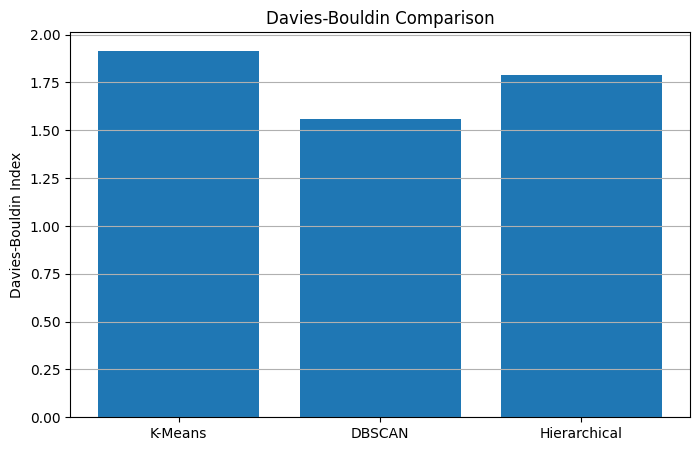

In [5]:
# =========================
# Davies-Bouldin Comparison
# =========================

plt.figure(figsize=(8, 5))

plt.bar(
    comparison_df["Algorithm"],
    comparison_df["Davies-Bouldin"]
)

plt.ylabel("Davies-Bouldin Index")

plt.title("Davies-Bouldin Comparison")

plt.grid(axis='y')
plt.savefig("../comparative/davies_bouldin_comparison.png")
plt.show()

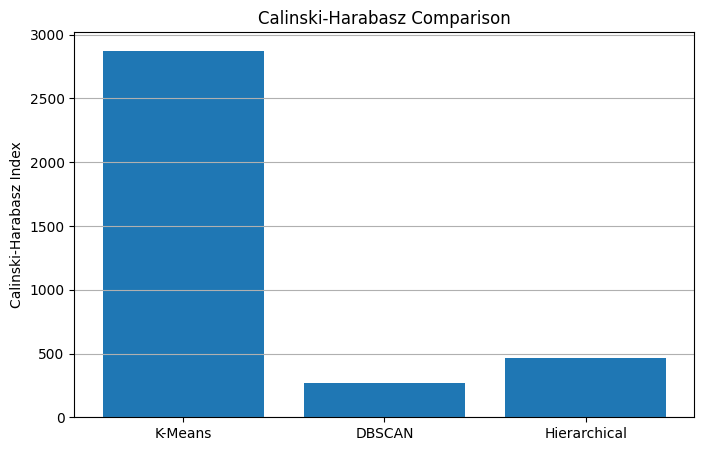

In [6]:
# =========================
# Calinski-Harabasz Comparison
# =========================

plt.figure(figsize=(8, 5))

plt.bar(
    comparison_df["Algorithm"],
    comparison_df["Calinski-Harabasz"]
)

plt.ylabel("Calinski-Harabasz Index")

plt.title("Calinski-Harabasz Comparison")

plt.grid(axis='y')
plt.savefig("../comparative/calinski_harabasz_comparison.png")
plt.show()

# Structural Interpretation of Clustering Behavior

The evaluated algorithms revealed fundamentally different perspectives of the epidemiological feature space.

## K-Means

K-Means imposed global centroid-based partitions over a predominantly continuous population structure. While the algorithm successfully identified broad macrosegments, strong overlap between clusters suggested that the underlying data distribution lacks naturally separated spherical groups.

## DBSCAN

DBSCAN achieved the best overall structural performance by preserving dense continuous regions and explicitly identifying sparse observations as noise. The algorithm revealed several localized high-density subpopulations and demonstrated robustness against irregular geometries and overlapping structures.

## Hierarchical Clustering

Hierarchical clustering captured gradual transitions and local connectivity more effectively than K-Means. However, the final partitioning process still forced discrete cuts over continuous regions, producing bridge-like macrostructures and chaining effects.

# Epidemiological Interpretation

The BRFSS dataset appears to represent a predominantly continuous epidemiological landscape rather than a collection of sharply separated population groups.

The results suggest:
- gradual transitions between health conditions,
- overlapping behavioral profiles,
- heterogeneous demographic structures,
- and localized high-risk subpopulations.

Density-based clustering revealed that rare or atypical health profiles may exist as sparse regions embedded within larger continuous population structures.

These findings align with the complexity typically observed in real-world public health systems, where behavioral, socioeconomic, and medical factors interact continuously rather than discretely.

# Limitations

Several limitations should be considered:

- PCA projection may compress relevant nonlinear structures
- DBSCAN sensitivity to hyperparameters may affect cluster stability
- Hierarchical clustering required subsampling due to computational complexity
- Self-reported survey data may introduce reporting bias
- Continuous epidemiological structures reduce the effectiveness of strict partition-based clustering methods

Future work could explore:
- HDBSCAN
- Gaussian Mixture Models
- Spectral Clustering
- nonlinear dimensionality reduction techniques such as UMAP or t-SNE

# Final Conclusion

This study evaluated three unsupervised learning approaches for discovering latent structures in the BRFSS public health dataset.

The results demonstrated that:
- the epidemiological feature space exhibits predominantly continuous population structures,
- density-aware methods outperform rigid centroid-based partitioning,
- and overlapping behavioral and demographic characteristics complicate global segmentation.

Among the evaluated methods, DBSCAN achieved the most coherent representation of the data by:
- preserving dense continuous regions,
- detecting anomalous observations,
- and adapting to irregular geometries.

These findings suggest that density-based approaches are particularly suitable for modeling heterogeneous public health populations characterized by gradual transitions and overlapping health profiles.

In [7]:
# =========================
# Save comparison table
# =========================

comparison_df.to_csv(
    "../results/clustering_comparison.csv",
    index=False
)

print("Comparison table saved successfully.")

Comparison table saved successfully.
